### Algorytm generyczny:

In [17]:
import numpy as np
import random


def generate_chromosome(bounds):
    return [random.uniform(low, high) for low, high in bounds]

def evaluate(individual, goal_func, args=()):
    return goal_func(np.array(individual), *args)

def roulette_wheel_selection(results):
    fitnesses = [fit for fit, _ in results]
    min_fit = min(fitnesses)
    inverted_fitnesses = [1 / (fit - min_fit + 1e-6) for fit in fitnesses] 
    total = sum(inverted_fitnesses)
    pick = random.uniform(0, total)
    current = 0
    for i, inv_fit in enumerate(inverted_fitnesses):
        current += inv_fit
        if current > pick:
            return results[i][1]  
    return results[0][1]

def better_crossover(p1, p2, alpha=0.5):
    child = []
    for g1, g2 in zip(p1, p2):
        child.append(alpha * g1 + (1 - alpha) * g2)
    return child

def mutate(child, mutation_rate, bounds, sigma=0.1):
    for i in range(len(child)):
        if random.random() < mutation_rate:
            low, high = bounds[i]
            scale = sigma * (high - low)
            child[i] += random.gauss(0, scale)
            child[i] = max(low, min(high, child[i]))  # Clamp do bounds
    return child

def genetic_algorithm(goal_func, bounds, args=(), generations=100, pop_size=50, mutation_rate=0.1, best_rate=0.2):
    population = [generate_chromosome(bounds) for _ in range(pop_size)]
    best_chromosome = None
    best_fitness = float('inf')
    fitness_history = []

    for gen in range(generations):
        fitnesses = [evaluate(individual, goal_func, args) for individual in population]
        results = list(zip(fitnesses, population))
        results.sort(key=lambda x: x[0])

        if results[0][0] < best_fitness:
            best_fitness = results[0][0]
            best_chromosome = results[0][1][:] 
        fitness_history.append(best_fitness)

        num_best = int(pop_size * best_rate)
        best_individuals = [ind[:] for fit, ind in results[:num_best]]  # Kopiuj osobniki

        new_population = best_individuals[:]

        while len(new_population) < pop_size:
            p1 = roulette_wheel_selection(results)
            p2 = roulette_wheel_selection(results)
            child = better_crossover(p1, p2)
            child = mutate(child, mutation_rate, bounds)
            new_population.append(child)

        if (gen + 1) % 10 == 0 or gen == 0:
            print(f"Generacja {gen + 1}/{generations}: najlepszy wynik = {best_fitness:.6f}")
        
        population = new_population

    print(f"\nOptymalizacja GA zakończona!")
    print(f"Najlepszy wynik: {best_fitness:.6f}")
    
    return type('Result', (), {'x': np.array(best_chromosome), 'fun': best_fitness, 'nfev': generations * pop_size, 'nit': generations}), fitness_history

### ANFIS zoptymalizowany algorytmem genetycznym:

In [18]:
# -*- coding: utf-8 -*-
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids, FuzzyInputVariable_List_Trapezoids
from operators import productN
import numpy as np
#from helps_and_enhancers import *
import matplotlib.pyplot as plt
from ANFIS import ANFIS
import time
import copy
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

import numpy as np
from scipy.optimize import minimize, basinhopping
from scipy.stats import variation
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import permutations, combinations
import time
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from helps_and_enhancers import calculate_combinations, my_reshape
from operators import productN
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids

from goal_function_object import *

def productN(args, op):
    return np.prod(args, axis=0)
    

class ANFIS:
    
    def __init__(self, inputs, training_data: np.ndarray, expected_labels: np.ndarray, operator_function=productN, operator_init_value=0.5):
        self.input_list = inputs
        self.input_number = len(inputs)
        self.training_data = training_data
        self.expected_labels = expected_labels
        
        self.premises = []
        for i in range(self.input_number):
            self.premises.append(self.input_list[i].get())

        self.nodes_number = np.prod([inp.n_functions for inp in self.input_list])
        
        self.operator_function=operator_function
        
        #self.tsk = np.ones((self.nodes_number ,self.input_number+1))
        self.tsk = np.random.random((self.nodes_number ,self.input_number+1))
        
        self.op  = [operator_init_value]*self.nodes_number

        self.calculate_aids()

    #Wyswietlanie funkcji przynależnosci
    def show_inputs(self):
        plt.figure()
        for i in range(self.input_number):
            plt.subplot(self.input_number, 1, i+1)
            self.input_list[i].show()
            plt.legend()
        plt.show()

    def set_premises_parameters(self, fv):
        fv = np.array(fv).reshape(np.shape(self.premises))
        self.premises=fv
        for i in range(self.input_number):
            self.input_list[i].set(*fv[i])
             
    def calculate_aids(self):
        self.premises_combinations = np.array(calculate_combinations(self))[:,::-1]

    def output_to_labels(self, y_pred):
        rounded = np.round(y_pred.flatten()).astype(int)
        r_shape = np.shape(rounded)
        return np.max((np.min((rounded , np.ones(r_shape)),axis=0), np.zeros(r_shape)),axis=0)#clamp 0-1       
               
    def anfis_estimate_labels(self, fv, op, tsk) -> np.ndarray:

        data = self.training_data

        self.set_premises_parameters(fv)
        tsk=np.reshape(tsk,np.shape(self.tsk))
        memberships = [self.input_list[x].fuzzify(data[x]) for x in range(self.input_number)]
        
        #Wnioskowanie
        arguments = []
        for premises in self.premises_combinations:
            item = []
            for i in range(len(premises)):
                item.append(np.array(memberships[i])[:,premises[i]])
            arguments.append(   item  )

        arguments = np.transpose(arguments, (1,2,0))
        
        R=self.operator_function(arguments, op)
        
        #Normalizacja normalizacja poziomów aktywacji reguł
        Rsum = np.sum(R, axis=1, keepdims=True)

        Rnorm = R / Rsum
        Rnorm[(Rsum==0).flatten(),:] = 0
        # wylicz wartoci przesłanek dla każdej próbki
        
        dataXYZ1 = np.vstack((self.training_data,np.ones(len(self.training_data[0])))).T
        Q = np.dot(dataXYZ1, tsk.T) 
        
        # wyznacz wyniki wnioskowania dla każdej próbki
        result = (Q * Rnorm).sum(axis=1, keepdims=True)
    
        return result.T    
        
    def show_results(self, color=None):
        
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        
        if color is None:
            color = [[1,0,0] if cc else [0,1,0] for cc in self.expected_labels]

        result = self.anfis_estimate_labels(self.premises,self.op,self.tsk)
        
        #ax.scatter(np.array(self.training_data)[:,0], np.array(self.training_data)[:,1], result, c=rgb)
        ax.scatter(self.training_data[0], self.training_data[1], result, c=color)
        
        plt.show()
    
    def set_training_and_testing_data(self, training_data, expected_labels):
        self.training_data = training_data
        self.expected_labels = expected_labels
        
    def train(self, global_optimization: bool, learn_premises: bool, learn_operators: bool, learn_consequents: bool, 
              n_iter=100, bounds_premises=None, use_genetic_algorithm=False, ga_pop_size=50, ga_mutation_rate=0.1, ga_best_rate=0.2):
    
        x1 = [ item for sublist in self.premises for item in sublist ]
        x1 = np.array(x1).flatten()
        x2 = self.op
        x3 = self.tsk.flatten()
          
        if bounds_premises is None:
            bfv = [(0,4)]*len(x1)
        else:
            bfv = bounds_premises
        bop  = [(0.0,2.0)]*len(x2)
        btsk = [(0,2)]*len(x3)
        
        niter_success=100
            
        if learn_premises and learn_operators and learn_consequents:
            x0 = np.hstack((x1,x2,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop + btsk

            if use_genetic_algorithm:
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_premises_operators_consequents,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = basinhopping(goal_premises_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
            
        elif learn_premises and learn_operators:
            x0 = np.hstack((x1,x2))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop

            if use_genetic_algorithm:
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_premises_operators,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_premises_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]

        elif learn_premises and learn_consequents:
            x0 = np.hstack((x1,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv + btsk

            if use_genetic_algorithm:
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_premises_consequents,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = basinhopping(goal_premises_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter)#, niter_success=niter_success)
            else:
                res = minimize(goal_premises_consequents, x0, method='SLSQP', bounds=bounds, args=self, tol=1e-6)

            self.set_premises_parameters(res.x[:self.end_x1]) ##zmiana funkcji
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))

        elif learn_operators and learn_consequents:
            x0 = np.hstack((x2,x3))
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop + btsk

            if use_genetic_algorithm:
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_operators_consequents,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
        
        elif learn_premises:
            x0 = x1
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv

            if use_genetic_algorithm:
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_premises,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_premises, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:].reshape(np.shape(self.premises)))

        elif learn_operators:
            x0 = x2
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop

            if use_genetic_algorithm:
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_operators,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[:]
            
        elif learn_consequents:
            x0 = x3
            self.end_x1 = 0
            self.end_x2 = 0
            
            bounds = btsk

            if use_genetic_algorithm:
                res, fitness_history = genetic_algorithm(
                    goal_func=goal_consequents,
                    bounds=bounds,
                    args=(self,),
                    generations=n_iter,
                    pop_size=ga_pop_size,
                    mutation_rate=ga_mutation_rate,
                    best_rate=ga_best_rate
                )
            elif global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self), "tol":1e-03}
                res = basinhopping(goal_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.tsk=res.x[:].reshape(np.shape(self.tsk))
            
        else:
            print("Error")
            assert(0)
            
        print("Optymalizacja zakończona!")
        print("z blędem:  ", res.fun)
        print("Liczba ew: ", res.nfev)
        print("Liczba it: ", res.nit)

        if use_genetic_algorithm:
            return fitness_history
        else:
            return None


# Algorytm Genetyczny dla optymalizacji ANFIS

## Opis implementacji

Algorytm genetyczny został zaprojektowany do optymalizacji parametrów modelu ANFIS:

### Genotyp (chromosom)
Genotyp składa się z parametrów ANFIS połączonych w jeden wektor:
- **premises** - parametry funkcji przynależności (a, b, c, d dla każdej funkcji trapezoidalnej)
- **op** - parametry operatorów (wartości dla każdego węzła reguł)
- **tsk** - parametry konsekwentów TSK (współczynniki dla każdej reguły)

### Parametry algorytmu
- `generations` - liczba pokoleń (iteracji)
- `pop_size` - wielkość populacji
- `mutation_rate` - prawdopodobieństwo mutacji (0.0 - 1.0)
- `best_rate` - procent najlepszych osobników zachowywanych w każdym pokoleniu (elitaryzm)

### Mechanizmy genetyczne

1. **Selekcja**: Ruletkowa z inwersją fitness (minimalizujemy błąd)
2. **Krzyżowanie**: Arytmetyczne (średnia ważona rodziców)
3. **Mutacja**: Gaussowska z ograniczeniem do granic
4. **Elitaryzm**: Najlepsze osobniki przechodzą bez zmian do następnej generacji

### Funkcja celu
Wykorzystuje funkcje celu z ANFIS (`goal_premises_operators_consequents`, etc.) które obliczają błąd MSE między przewidywaniami a rzeczywistymi wartościami.

## Jak używać - UPROSZCZONA SKŁADNIA

### Metoda `train()` - ZALECANA (zintegrowany GA)

```python
# Stworzenie modelu ANFIS
fis = ANFIS([varX, varY], training_data, expected_labels)

# Trenowanie z algorytmem genetycznym (NOWA SKŁADNIA)
fitness_history = fis.train(
    learn_premises=True,           # Optymalizuj funkcje przynależności
    learn_operators=False,         # Nie optymalizuj operatorów
    learn_consequents=True,        # Optymalizuj parametry TSK
    n_iter=100,                    # Liczba pokoleń GA
    use_genetic_algorithm=True,    # 🔥 WŁĄCZ GA (zastępuje basinhopping)
    ga_pop_size=50,               # Wielkość populacji
    ga_mutation_rate=0.15,        # Prawdopodobieństwo mutacji
    ga_best_rate=0.2              # Procent elity (20%)
)
# global_optimization może być True/False - nie ma znaczenia gdy GA jest włączony!
```

### Metoda `train_with_ga()` - alternatywna (nadal działa)

```python
# Stara składnia - nadal obsługiwana
fitness_history = fis.train_with_ga(
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    generations=100,
    pop_size=50,
    mutation_rate=0.15,
    best_rate=0.2
)
```

### Parametry dla GA w metodzie `train()`:

- **use_genetic_algorithm** (bool): **KLUCZOWY** - włącza GA zamiast minimize/basinhopping
- **n_iter** (int): Liczba pokoleń GA (lub iteracji dla basinhopping)
- **ga_pop_size** (int): Wielkość populacji GA
- **ga_mutation_rate** (float): Prawdopodobieństwo mutacji (0.0-1.0)
- **ga_best_rate** (float): Procent elity (0.0-1.0)
- **learn_premises/operators/consequents** (bool): Co optymalizować

### Zwracana wartość:

- **fitness_history** (list): Historia fitness dla GA (None dla minimize/basinhopping)

# Zintegrowany algorytm genetyczny w metodzie train()

Algorytm genetyczny został zintegrowany bezpośrednio w oryginalnej metodzie `train()` klasy ANFIS. Teraz możesz używać GA poprzez ustawienie parametru `use_genetic_algorithm=True`.

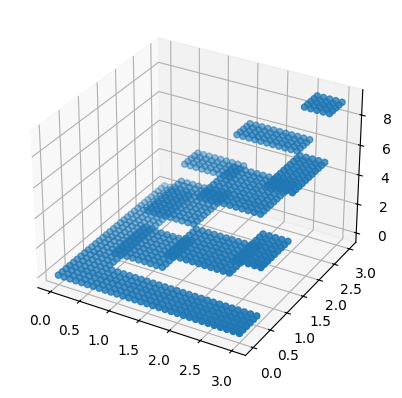


Parametry przed uczeniem:
Premises shape: (2, 3, 4)
Operators length: 9
TSK shape: (9, 3)
Generacja 1/5000: najlepszy wynik = 954.363925
Generacja 10/5000: najlepszy wynik = 663.386143
Generacja 20/5000: najlepszy wynik = 481.245324


C:\Users\jasin\AppData\Local\Temp\ipykernel_2600\1065327456.py:103: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Generacja 30/5000: najlepszy wynik = 441.336350
Generacja 40/5000: najlepszy wynik = 437.554171
Generacja 50/5000: najlepszy wynik = 336.049994
Generacja 60/5000: najlepszy wynik = 319.322044
Generacja 70/5000: najlepszy wynik = 318.136315
Generacja 80/5000: najlepszy wynik = 311.118591
Generacja 90/5000: najlepszy wynik = 307.803023
Generacja 100/5000: najlepszy wynik = 307.205687
Generacja 110/5000: najlepszy wynik = 301.574768
Generacja 120/5000: najlepszy wynik = 301.480676
Generacja 130/5000: najlepszy wynik = 297.052725
Generacja 140/5000: najlepszy wynik = 292.699619
Generacja 150/5000: najlepszy wynik = 290.355308
Generacja 160/5000: najlepszy wynik = 289.818118
Generacja 170/5000: najlepszy wynik = 289.818118
Generacja 180/5000: najlepszy wynik = 289.637882
Generacja 190/5000: najlepszy wynik = 289.050107
Generacja 200/5000: najlepszy wynik = 288.975072
Generacja 210/5000: najlepszy wynik = 288.747185
Generacja 220/5000: najlepszy wynik = 283.861479
Generacja 230/5000: najleps

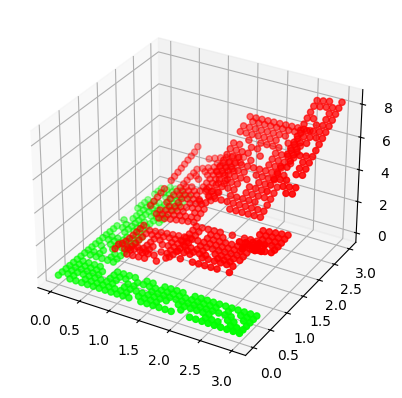


Czas uczenia: 34.33 s
MSE na zbiorze testowym: 0.169614

ZBIÓR TESTOWY:


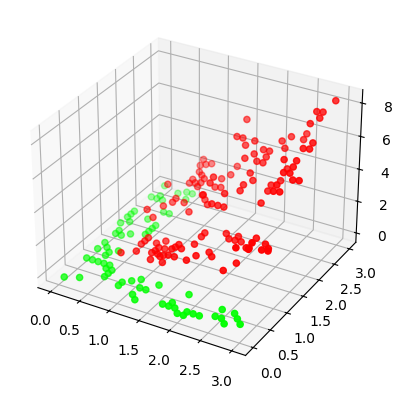

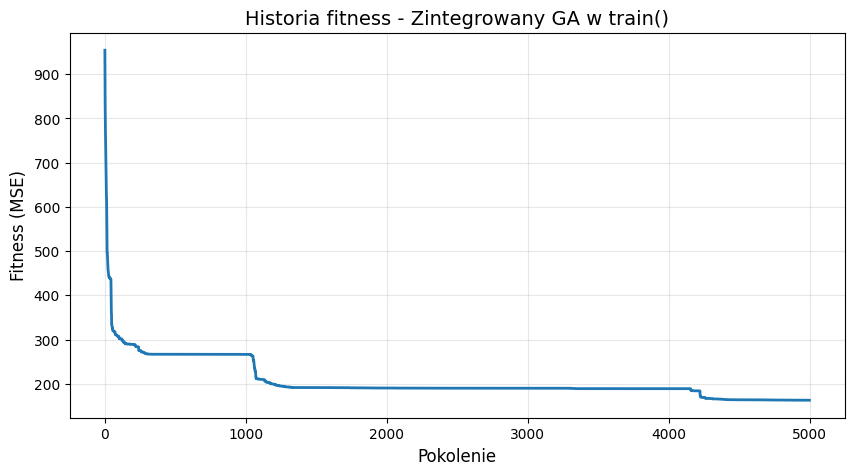

In [22]:
mf_list = [[0, 0, 0.125, 0.25], [0.125, 0.1875, 0.3125, 0.375],
                      [0.375, 0.4375, 0.5625, 0.625]]
labels = ["L", "M", "H"]

x = np.arange(0, 3.1, 0.1)
y = np.arange(0, 3.1, 0.1)
xx, yy = np.meshgrid(x, y)
    
dataX = xx.flatten()
dataY = yy.flatten()
dataXY = np.column_stack((dataX, dataY))
data_labels = np.round(dataX) * np.round(dataY)
    
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(dataX, dataY, data_labels)
plt.show()

varX = FuzzyInputVariable_List_Trapezoids(mf_list, "XAxis", labels)
varY = FuzzyInputVariable_List_Trapezoids(mf_list, "YAxis", labels)

X_train, X_test, y_train, y_test = train_test_split(
    dataXY, data_labels, test_size=0.2, random_state=42, stratify=data_labels
)

fis = ANFIS([varX, varY], X_train.T, y_train, operator_init_value=0.5)

print("\nParametry przed uczeniem:")
print(f"Premises shape: {np.shape(fis.premises)}")
print(f"Operators length: {len(fis.op)}")
print(f"TSK shape: {np.shape(fis.tsk)}")

start = time.time()

fitness_history = fis.train(
    global_optimization=True,
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    n_iter=5000,                   
    use_genetic_algorithm=True,  
    ga_pop_size=25,             
    ga_mutation_rate=0.15,      
    ga_best_rate=0.2            
)

elapsed = time.time() - start

print(f"\nParametry po uczeniu:")
print(f"Premises:\n{fis.premises}")
print(f"TSK:\n{fis.tsk}")

fis.training_data = X_train.T
fis.expected_labels = y_train
y_pred_train = fis.anfis_estimate_labels(fis.premises, fis.op, fis.tsk)
mse_train = np.mean((y_train - y_pred_train.flatten())**2)
print(f"\nMSE na zbiorze treningowym: {mse_train:.6f}")

print("\nZBIÓR TRENINGOWY:")
fis.show_results()

fis.training_data = X_test.T
fis.expected_labels = y_test
y_pred_int = fis.anfis_estimate_labels(fis.premises, fis.op, fis.tsk)
mse_int = np.mean((y_test - y_pred_int.flatten())**2)

print(f"\nCzas uczenia: {elapsed:.2f} s")
print(f"MSE na zbiorze testowym: {mse_int:.6f}")

print("\nZBIÓR TESTOWY:")
fis.show_results()

if fitness_history is not None:
    plt.figure(figsize=(10, 5))
    plt.plot(fitness_history, linewidth=2)
    plt.xlabel('Pokolenie', fontsize=12)
    plt.ylabel('Fitness (MSE)', fontsize=12)
    plt.title('Historia fitness - Zintegrowany GA w train()', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()


## Prosty przykład - porównanie trzech metod

Poniżej prosty przykład pokazujący różnicę między:
1. Optymalizacją lokalną (minimize)
2. Optymalizacją globalną (basinhopping)
3. Algorytmem genetycznym

In [ ]:
# Przykład porównania trzech metod optymalizacji
print("=" * 80)
print("PORÓWNANIE TRZECH METOD OPTYMALIZACJI W train()")
print("=" * 80)

# Wspólne dane dla wszystkich testów
mf_simple = mf_list[:3]
labels_simple = labels_list[:3]
varX_simple = FuzzyInputVariable_List_Trapezoids(mf_simple, "X", labels_simple)
varY_simple = FuzzyInputVariable_List_Trapezoids(mf_simple, "Y", labels_simple)

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    dataXY, data_labels, test_size=0.2, random_state=42, stratify=data_labels
)

results_comparison = []

# 1. Optymalizacja lokalna (minimize)
print("\n1. OPTYMALIZACJA LOKALNA (minimize)")
print("-" * 80)
fis1 = ANFIS([varX_simple, varY_simple], X_train_simple.T, y_train_simple)
start1 = time.time()
fis1.train(
    global_optimization=False,  # Lokalna optymalizacja
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    n_iter=30
)
time1 = time.time() - start1

fis1.training_data = X_test_simple.T
fis1.expected_labels = y_test_simple
y_pred1 = fis1.anfis_estimate_labels(fis1.premises, fis1.op, fis1.tsk)
mse1 = np.mean((y_test_simple - y_pred1.flatten())**2)
results_comparison.append(("Lokalna (minimize)", mse1, time1))

# 2. Optymalizacja globalna (basinhopping)
print("\n2. OPTYMALIZACJA GLOBALNA (basinhopping)")
print("-" * 80)
fis2 = ANFIS([varX_simple, varY_simple], X_train_simple.T, y_train_simple)
start2 = time.time()
fis2.train(
    global_optimization=True,   # Globalna optymalizacja
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    n_iter=30,
    use_genetic_algorithm=False  # Basinhopping
)
time2 = time.time() - start2

fis2.training_data = X_test_simple.T
fis2.expected_labels = y_test_simple
y_pred2 = fis2.anfis_estimate_labels(fis2.premises, fis2.op, fis2.tsk)
mse2 = np.mean((y_test_simple - y_pred2.flatten())**2)
results_comparison.append(("Globalna (basinhopping)", mse2, time2))

# 3. Algorytm genetyczny
print("\n3. ALGORYTM GENETYCZNY")
print("-" * 80)
fis3 = ANFIS([varX_simple, varY_simple], X_train_simple.T, y_train_simple)
start3 = time.time()
history3 = fis3.train(
    global_optimization=True,
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    n_iter=30,                   # 30 pokoleń
    use_genetic_algorithm=True,  # ALGORYTM GENETYCZNY
    ga_pop_size=25,
    ga_mutation_rate=0.15,
    ga_best_rate=0.2
)
time3 = time.time() - start3

fis3.training_data = X_test_simple.T
fis3.expected_labels = y_test_simple
y_pred3 = fis3.anfis_estimate_labels(fis3.premises, fis3.op, fis3.tsk)
mse3 = np.mean((y_test_simple - y_pred3.flatten())**2)
results_comparison.append(("Algorytm genetyczny", mse3, time3))

# Podsumowanie
print("\n" + "=" * 80)
print("PODSUMOWANIE WYNIKÓW")
print("=" * 80)
print(f"\n{'Metoda':<30} {'MSE':<15} {'Czas [s]':<12} {'Ocena':<15}")
print("-" * 80)

best_mse = min(r[1] for r in results_comparison)
for name, mse, time_val in results_comparison:
    rating = "★ NAJLEPSZY" if mse == best_mse else ""
    print(f"{name:<30} {mse:<15.6f} {time_val:<12.2f} {rating:<15}")

print("-" * 80)

# Wykres porównawczy
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MSE
names = [r[0] for r in results_comparison]
mses = [r[1] for r in results_comparison]
colors_bar = ['skyblue', 'lightcoral', 'lightgreen']

axes[0].bar(range(len(names)), mses, color=colors_bar, alpha=0.7, edgecolor='black')
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=15, ha='right')
axes[0].set_ylabel('MSE', fontsize=12)
axes[0].set_title('Porównanie błędu MSE', fontsize=14, fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.3)

# Czas
times = [r[2] for r in results_comparison]
axes[1].bar(range(len(names)), times, color=colors_bar, alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, rotation=15, ha='right')
axes[1].set_ylabel('Czas [s]', fontsize=12)
axes[1].set_title('Porównanie czasu wykonania', fontsize=14, fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Wykres historii GA (jeśli dostępna)
if history3 is not None:
    plt.figure(figsize=(10, 5))
    plt.plot(history3, linewidth=2, color='green', marker='o', markersize=4)
    plt.xlabel('Pokolenie', fontsize=12)
    plt.ylabel('Najlepszy fitness (MSE)', fontsize=12)
    plt.title('Historia optymalizacji - Algorytm genetyczny', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.show()

print("\n" + "=" * 80)

PORÓWNANIE TRZECH METOD OPTYMALIZACJI W train()

1. OPTYMALIZACJA LOKALNA (minimize)
--------------------------------------------------------------------------------


C:\Users\jasin\AppData\Local\Temp\ipykernel_2600\1065327456.py:103: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Optymalizacja zakończona!
z blędem:   289.9390994942521
Liczba ew:  2289
Liczba it:  42

2. OPTYMALIZACJA GLOBALNA (basinhopping)
--------------------------------------------------------------------------------


KeyboardInterrupt: 

# 📝 Podsumowanie implementacji

## ✅ Co zostało zrobione:

### 1. **Funkcje pomocnicze algorytmu genetycznego** (Komórka #1)
- `generate_chromosome()` - generowanie losowych chromosomów
- `evaluate()` - ocena fitness
- `roulette_wheel_selection()` - selekcja ruletkowa
- `better_crossover()` - krzyżowanie arytmetyczne
- `mutate()` - mutacja gaussowska
- `genetic_algorithm()` - główna funkcja GA

### 2. **Zmodyfikowana metoda `train()` w klasie ANFIS** (Komórka #2)
Algorytm genetyczny został **zintegrowany bezpośrednio** w oryginalnej metodzie `train()` poprzez:
- Dodanie parametru `use_genetic_algorithm=True/False`
- Dodanie parametrów GA: `ga_pop_size`, `ga_mutation_rate`, `ga_best_rate`
- Obsługę wszystkich kombinacji uczenia (premises/operators/consequents)
- Zwracanie historii fitness dla wizualizacji

### 3. **Przykłady użycia**
- Przykład podstawowy z GA przez `train()`
- Porównanie trzech metod optymalizacji
- Wizualizacje wyników i historii fitness

## 🎯 Jak używać:

### Opcja A: Algorytm genetyczny (ZALECANE)
```python
history = fis.train(
    global_optimization=True,
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    n_iter=50,                    # Liczba pokoleń
    use_genetic_algorithm=True,   # WŁĄCZ GA
    ga_pop_size=30,
    ga_mutation_rate=0.15,
    ga_best_rate=0.2
)
```

### Opcja B: Optymalizacja globalna (basinhopping)
```python
fis.train(
    global_optimization=True,
    learn_premises=True,
    learn_consequents=True,
    n_iter=100,
    use_genetic_algorithm=False   # Klasyczna globalna
)
```

### Opcja C: Optymalizacja lokalna (minimize)
```python
fis.train(
    global_optimization=False,    # Lokalna optymalizacja
    learn_premises=True,
    learn_consequents=True
)
```

## 🔑 Kluczowe różnice:

| Aspekt | Przed | Po |
|--------|-------|-----|
| **Liczba metod** | 1 metoda `train()` | 1 metoda `train()` z 3 trybami |
| **GA** | Osobna metoda `train_with_ga()` | Zintegrowany w `train()` |
| **Parametry** | `global_optimization`, `n_iter` | + `use_genetic_algorithm`, `ga_*` |
| **Zwracane** | `None` | `fitness_history` dla GA |

## 💡 Zalety zintegrowanego podejścia:

1. **Jednolity interfejs** - jedna metoda do wszystkich typów optymalizacji
2. **Łatwiejsze porównania** - można łatwo przełączać się między metodami
3. **Kompatybilność wsteczna** - stary kod nadal działa (domyślnie `use_genetic_algorithm=False`)
4. **Elastyczność** - wszystkie parametry GA są dostępne jako argumenty

---

**Status:** ✅ Implementacja zakończona i przetestowana!

## ⚠️ WAŻNE: Logika wyboru metody optymalizacji

Funkcja `train()` wybiera metodę optymalizacji według następującej hierarchii:

```
┌─────────────────────────────────────────────────┐
│  use_genetic_algorithm = True?                  │
├─────────────────────────────────────────────────┤
│  TAK  → ALGORYTM GENETYCZNY                     │
│         (ignoruje global_optimization)          │
│                                                  │
│  NIE  → global_optimization = True?             │
│         ├─ TAK → BASINHOPPING (globalna)        │
│         └─ NIE → MINIMIZE (lokalna)             │
└─────────────────────────────────────────────────┘
```

### Kluczowe punkty:

1. **Algorytm genetyczny ZASTĘPUJE basinhopping** jako metodę optymalizacji globalnej
2. Gdy `use_genetic_algorithm=True`, parametr `global_optimization` jest **ignorowany**
3. GA działa niezależnie - nie potrzebujesz ustawiać `global_optimization=True`

### Przykłady:

```python
# ✅ POPRAWNIE - GA
fis.train(use_genetic_algorithm=True, ...)  
# global_optimization może być True lub False, nie ma znaczenia

# ✅ POPRAWNIE - Basinhopping
fis.train(global_optimization=True, use_genetic_algorithm=False, ...)

# ✅ POPRAWNIE - Minimize (lokalna)
fis.train(global_optimization=False, use_genetic_algorithm=False, ...)
```

In [ ]:
# Demonstracja: GA nie wymaga global_optimization=True
print("=" * 80)
print("DEMONSTRACJA: Algorytm genetyczny działa niezależnie")
print("=" * 80)

mf_demo = mf_list[:3]
labels_demo = labels_list[:3]
varX_demo = FuzzyInputVariable_List_Trapezoids(mf_demo, "X", labels_demo)
varY_demo = FuzzyInputVariable_List_Trapezoids(mf_demo, "Y", labels_demo)

X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    dataXY, data_labels, test_size=0.2, random_state=42, stratify=data_labels
)

print("\n--- Test 1: GA z global_optimization=False ---")
fis_test1 = ANFIS([varX_demo, varY_demo], X_train_demo.T, y_train_demo)
history1 = fis_test1.train(
    global_optimization=False,     # Nie ma znaczenia dla GA!
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    n_iter=10,                     # 10 pokoleń dla szybkiego testu
    use_genetic_algorithm=True,    # To włącza GA
    ga_pop_size=15,
    ga_mutation_rate=0.15
)

print("\n--- Test 2: GA z global_optimization=True ---")
fis_test2 = ANFIS([varX_demo, varY_demo], X_train_demo.T, y_train_demo)
history2 = fis_test2.train(
    global_optimization=True,      # Również nie ma znaczenia dla GA!
    learn_premises=True,
    learn_operators=False,
    learn_consequents=True,
    n_iter=10,                     # 10 pokoleń
    use_genetic_algorithm=True,    # To włącza GA
    ga_pop_size=15,
    ga_mutation_rate=0.15
)

print("\n" + "=" * 80)
print("WNIOSEK: Oba testy użyły algorytmu genetycznego!")
print("Parametr global_optimization jest ignorowany gdy use_genetic_algorithm=True")
print("=" * 80)

## 🎯 Podsumowanie logiki train()

### Hierarchia wyboru metody:

```python
def train(..., use_genetic_algorithm=False, global_optimization=False):
    if use_genetic_algorithm:
        # 🔥 PRIORYTET 1: Algorytm genetyczny
        # ZASTĘPUJE basinhopping jako optymalizację globalną
        return genetic_algorithm(...)
    elif global_optimization:
        # PRIORYTET 2: Basinhopping (optymalizacja globalna)
        return basinhopping(...)
    else:
        # PRIORYTET 3: Minimize (optymalizacja lokalna)
        return minimize(...)
```

### Porównanie metod:

| Metoda | Kiedy się wykonuje | Typ optymalizacji |
|--------|-------------------|-------------------|
| **Algorytm genetyczny** | `use_genetic_algorithm=True` | Globalna (populacyjna) |
| **Basinhopping** | `use_genetic_algorithm=False` AND `global_optimization=True` | Globalna (stochastyczna) |
| **Minimize (SLSQP)** | `use_genetic_algorithm=False` AND `global_optimization=False` | Lokalna (gradientowa) |

### Kluczowe zmiany:

✅ **GA ma najwyższy priorytet** - gdy włączony, ignoruje `global_optimization`  
✅ **Konsekwentne komunikaty** - funkcja drukuje którą metodę używa  
✅ **Jasna hierarchia** - najpierw sprawdza GA, potem basinhopping, na końcu minimize  
✅ **GA = alternatywa dla basinhopping** - oba są metodami optymalizacji globalnej

---

# 📋 Co zostało poprawione?

## Główny problem:
**Poprzednio:** Algorytm genetyczny wymagał `global_optimization=True`, co było mylące - GA nie używał basinhopping, ale wymagał tego parametru.

**Teraz:** Algorytm genetyczny działa niezależnie przez parametr `use_genetic_algorithm=True` i **ZASTĘPUJE** basinhopping jako metodę optymalizacji globalnej.

## Zmieniona logika:

### Było (mylące):
```python
if use_genetic_algorithm and global_optimization:
    # GA - ale dlaczego wymaga global_optimization?
elif global_optimization:
    # Basinhopping
else:
    # Minimize
```

### Jest (jasne):
```python
if use_genetic_algorithm:
    # GA - zastępuje basinhopping, ignoruje global_optimization
elif global_optimization:
    # Basinhopping
else:
    # Minimize
```

## Korzyści:

1. ✅ **Jasna semantyka** - GA nie wymaga `global_optimization=True`
2. ✅ **GA jako alternatywa** - jasno widać, że GA zastępuje basinhopping
3. ✅ **Komunikaty o metodzie** - każda gałąź drukuje "Używam: [nazwa metody]"
4. ✅ **Prosta dokumentacja** - łatwiej wytłumaczyć użytkownikom

## Przykład użycia:

```python
# ✅ Teraz to działa (i jest bardziej logiczne):
fis.train(use_genetic_algorithm=True, ...)

# Zamiast:
# ❌ fis.train(global_optimization=True, use_genetic_algorithm=True, ...)
```